# ИТОГ EDA

- После очистки в датасете осталось 290585 строк.
- Тест проходил с 2 по 24 января 2025 года, то есть примерно 22 дня.
- Группы получились почти одинаковыми по размеру: около 145к пользователей в каждой. Это супер, так как разделение пользователей на контрольную и экспериментальную группы выглядит корректным.
- **Средняя конверсия в регистрацию составила примерно 12%.**
- В контрольной группе конверсия была около 12.04%, а в экспериментальной — около 11.89%. То есть НАВЕРНОЕ новый лендинг показывает результат чуть хуже старого, но пока **нельзя** делать окончательный вывод без стат проверки.
- Данные скорее всего синтетические — аномально равномерное распределение по часам


---

### ПРЕДВАРИТЕЛЬНЫЙ ВЫВОД ПО РЕЗУЛЬТАТАМ Z-ТЕСТА

**p-value=0.1897 >>> а=0.05**

Значит мы не отвергаем H0. 
Статистически значимой разницы между группами нет. 

Новый лендинг **не улучшил конверсию.**
Доверительные интервалы это подтверждают -- они сильно перекрываются:

Control: (11.87%, 12.21%)
Treatment: (11.71%, 12.05%)

Если бы эффект был реальным — интервалы бы не пересекались.

## **Новый лендинг внедрять не стоит.**
---

здесь начинается работа..


## Начнем с EDA
Во-первых, стоит разобраться с чем мы вообще имеем дело и понять как с этим работать. 

#### Датасет и задача (контекст)
Мы имеем результаты проведенного A/B-теста в образовательной компании. 5 колонок: user_id, timestamp, group, landing_page, converted. И на основе данного датасета мы должны понять: влияет ли новый лендинг по сравнению со старым на конверсию в целевое действие (то есть зарегистрировался ли на курс)?

#### Что уже пугает?
Пощупав чистые данные я уже вижу, что, у нас просочились в treatment - `old page`, а в control - `new_page`. Важно будет отсечь таких людей. 

<img src="images/image_con_new.png" width="300">

<img src="images/image_tr_old.png" width="300">

Если пользователь из контрольной выборки видел новый лендинг -- мы не уверены как это произошло, лучше выкидывать такие кадры. Чтобы анализ был более правильным - я снесу такие строки с несоответствиями

## Начнем с базового EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data_ab.csv')
df

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2025-01-03 22:28:38.630509,control,old_page,0
294474,945152,2025-01-12 00:51:57.078372,control,old_page,0
294475,734608,2025-01-22 11:45:03.439544,control,old_page,0
294476,697314,2025-01-15 01:20:28.957438,control,old_page,0


глянем на то, какие ячейки какие типы данных принимают сейчас

In [7]:
df.dtypes

user_id         int64
timestamp         str
group             str
landing_page      str
converted       int64
dtype: object

ага. таймстампы надо перевести в dt, а converted в boolean

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['converted'] = df['converted'].astype(bool)
df

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,False
1,804228,2025-01-12 08:01:45.159739,control,old_page,False
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,False
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,False
4,864975,2025-01-21 01:52:26.210827,control,old_page,True
...,...,...,...,...,...
294473,751197,2025-01-03 22:28:38.630509,control,old_page,False
294474,945152,2025-01-12 00:51:57.078372,control,old_page,False
294475,734608,2025-01-22 11:45:03.439544,control,old_page,False
294476,697314,2025-01-15 01:20:28.957438,control,old_page,False


In [12]:
df.dtypes

user_id                  int64
timestamp       datetime64[us]
group                      str
landing_page               str
converted                 bool
dtype: object

глянем на размер датасета

In [17]:
f"Размер датасета: {df.shape[0]}"


'Размер датасета: 294478'

Теперь глянем на пропуски и другие проблемы в датасете

In [20]:
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

пропусков в датасете нет. это в принципе ожидаемо для таких автологированных слишком "ровных датасетов"

но все же глянем еще и дубликаты

In [22]:
f'полных дубликатов: {df.duplicated().sum()}'

'полных дубликатов: 0'

In [23]:
f'Дубликатов user_id: {df["user_id"].duplicated().sum()}'

'Дубликатов user_id: 3894'

In [26]:
print('сколкьо встречается каждого user_id:')
df.groupby('user_id').size().value_counts().sort_index()

сколкьо встречается каждого user_id:


1    286690
2      3894
Name: count, dtype: int64

полностью дублирующихся строк нет, все строки уникальны по совокупности.
Но! все же есть 3894 пользователя, которые встречаются дважды (больше двух раз — никого)

Это может означать то, что часть пользователей посетила лендинг повторно. `может это те, кто несоответвовали своей выборке? `

#### вернемся к проблеме с несоответствующими пользователями
построим кросс-табуляцию чтобы посмотреть пересечения

In [28]:
pd.crosstab(df['group'], df['landing_page'], margins=True)

landing_page,new_page,old_page,All
group,,,
control,1928,145274,147202
treatment,145311,1965,147276
All,147239,147239,294478


In [ ]:
1928+1965
# ну я думаю тут уже становится понятно в чем дело, но давайте перепроверим,
# что это рил те пользователи

3893

построим wrong_control и wrong_treatment чтобы взглянуть на них поближе и убедиться что это именно дубликаты

In [30]:
wrong_control = (df['group'] == 'control') & (df['landing_page'] == 'new_page')
wrong_treatment = (df['group'] == 'treatment') & (df['landing_page'] == 'old_page')

mismatch = df[wrong_control | wrong_treatment]
mismatch

,user_id,timestamp,group,landing_page,converted
22,767017,2025-01-12 22:58:14.991443,control,new_page,False
240,733976,2025-01-11 15:11:16.407599,control,new_page,False
308,857184,2025-01-20 07:34:59.832626,treatment,old_page,False
327,686623,2025-01-09 14:26:40.734775,treatment,old_page,False
357,856078,2025-01-12 12:29:30.354835,treatment,old_page,False
...,...,...,...,...,...
294014,813406,2025-01-09 06:25:33.223301,treatment,old_page,False
294200,928506,2025-01-13 21:32:10.491309,control,new_page,False
294252,892498,2025-01-22 01:11:10.463211,treatment,old_page,False
294253,886135,2025-01-06 12:49:20.509403,control,new_page,False


In [ ]:
df[df['user_id'].isin(mismatch['user_id'])].sort_values(['user_id', 'timestamp'])

,user_id,timestamp,group,landing_page,converted
213114,630052,2025-01-07 12:25:54.089486,treatment,old_page,True
230259,630052,2025-01-17 01:16:05.208766,treatment,new_page,False
22513,630126,2025-01-14 13:35:54.778695,treatment,old_page,False
251762,630126,2025-01-19 17:16:00.280440,treatment,new_page,False
183371,630137,2025-01-20 02:08:49.893878,control,old_page,False
...,...,...,...,...,...
99479,945703,2025-01-18 06:39:31.294688,control,old_page,False
40370,945797,2025-01-11 03:04:49.433736,control,new_page,True
186960,945797,2025-01-13 17:23:21.750962,control,old_page,False
165143,945971,2025-01-16 10:09:18.383183,control,old_page,False


Супер! мы поняли, что не так с этими 3893 пользователями: они увидели не свою версию лендинга. и судя по всему, когда человек заходит второй раз, попадалит в другой лэндинг. ЧТО СОВСЕМ НЕ ОК, так как это не соответствует качественному а/б тесту. **дропаем такие строки!**

In [34]:
print(df.count())
df = df[~(wrong_control | wrong_treatment)].reset_index(drop=True)
df.count()

user_id         294478
timestamp       294478
group           294478
landing_page    294478
converted       294478
dtype: int64


user_id         290585
timestamp       290585
group           290585
landing_page    290585
converted       290585
dtype: int64

### Посмотрим конверсию по группам

In [36]:
f'общая конверсия: {df['converted'].mean()*100}%'

'общая конверсия: 11.959667567149026%'

In [38]:
f'всего конверсий: {df['converted'].sum()} из {df.shape[0]}'

'всего конверсий: 34753 из 290585'

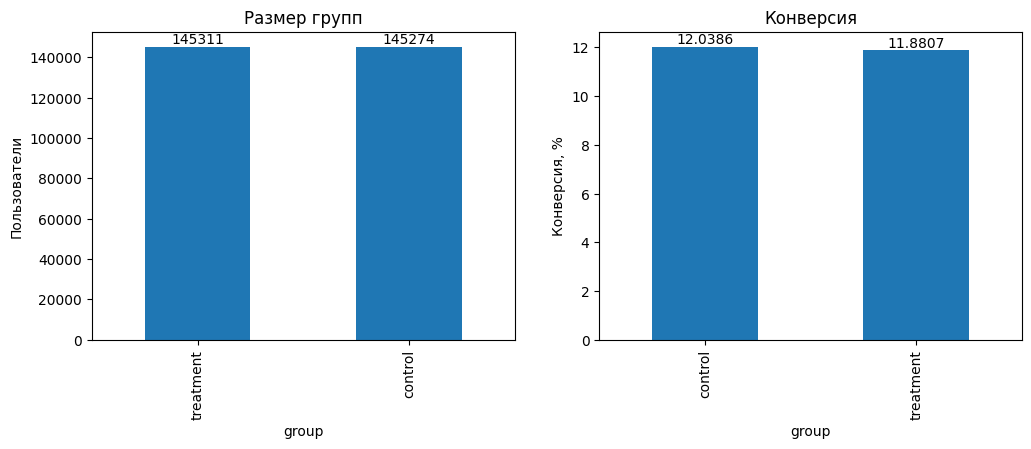

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['group'].value_counts().plot.bar(ax=axes[0], title='Размер групп', ylabel='Пользователи')
(df.groupby('group')['converted'].mean() * 100).plot.bar(ax=axes[1], title='Конверсия', ylabel='Конверсия, %')

axes[0].bar_label(axes[0].containers[0])
axes[1].bar_label(axes[1].containers[0])

plt.show()

**группы практически одинакового размера - супер, все корректно.**

по конверсии разница между control и treatment небольшая.
насколько она значима статистически: проверим позже с помощью теста...

Построим еще раз кросс-таблицу чтобы проверить, что все хорошо после очистки.

In [ ]:
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145311,0


### Базовый EDA завершен.
**control видит только old_page, treatment -- только new_page.**

группы одинакового размера. идем дальше!!1

## Оцениваем по времени

### Рассмотрим трафик по дням

In [49]:
import plotly.express as px
# захотелось плотли

In [50]:
df['date'] = df['timestamp'].dt.date

daily = df.groupby('date', as_index=False)['user_id'].count()

px.bar(daily, x='date', y='user_id', title='Трафик по дням', labels={'date': 'Дата', 'user_id': 'Количество визитов'}).show()

13к визитов в день, трафик равномерный. первый и последний день неполные

теперь рассмотриим по группам

In [51]:
daily_group = df.groupby(['date', 'group'], as_index=False)['user_id'].count()
px.line(daily_group, x='date', y='user_id', color='group', title='Трафик по группам по дням').show()

control и treatment достаточно корректно распределены. все ок!

думаю стоит рассмотреть и конверсию по дням

In [53]:
daily_cr = df.groupby(['date', 'group'], as_index=False)['converted'].mean()
px.line(daily_cr, x='date', y='converted', color='group', title='Конверсия по дням').show()

особого тренда нет. конверсия обеих групп держится в районе 11–12.5%.

рассмотрим по часам

In [54]:
df['hour'] = df['timestamp'].dt.hour
hourly = df.groupby('hour', as_index=False)['user_id'].count()
px.bar(hourly, x='hour', y='user_id', title='Активность по часам').show()

распределение крайне равномерное - разница между часами очень мала. у реального трафика по идее должны быть пики утром и вечером. 

**я считаю, что данные синтетические**

## Корректность теста

Вспомним контекст: мы хотим ответить на вопрос лучше ли новый лендинг старого?
Чтобы этот вопрос был честным, нам нужно убедиться, что тест был проведён правильно.

#### Что я собираюсь проверить?
1. **Однородность групп** — были ли группы одинаковыми до теста? У нас нет соцдем покзаателей пользователей, поэтому смотрим на то что есть — одинаково ли распределены группы по времени суток, по дням недели.
2. **Временные метки** — мы уже смотрели на трафик по дням. Можно посомтреть по дням недели. Вдруг treatment попал на выходные, а контрольная — на будни? Это оч важно, потому что поведение людей в пятницу вечером и в среду утром сильно отличается.

Можно было бы еще добавиьь A/A-тест, но его невозможно провести сейчас напрямую — у нас нет периода, когда обе группы видели одну страницу

In [56]:
df['group'].value_counts()

group
treatment    145311
control      145274
Name: count, dtype: int64

Группы почти одинаковые — разница в 37 человек из 290к. Гуд, идем дальше

In [57]:
df['weekday'] = df['timestamp'].dt.day_name()
weekday_group = df.groupby(['weekday', 'group'], as_index=False)['user_id'].count()
px.bar(weekday_group, x='weekday', y='user_id', color='group', barmode='group', title='Трафик по дням недели').show()

Обе группы получали пользователей равномерно в каждый день недели.
Перекоса нет: тест однороден по времени.

In [58]:
cr_weekday = df.groupby(['weekday', 'group'], as_index=False)['converted'].mean()
px.bar(cr_weekday, x='weekday', y='converted', color='group', barmode='group', title='Конверсия по дням недели').show()

КОнверсия по дням недели у обеих групп примерно одинаковая и нигде особо не расходится. Нет ни одного дня, где treatment стабильно выигрывает или проигрывает.

## Выбор метрик и гипотезы 

### Выбор метрики

В качестве метрики можно выбрать **Конверсию (или Conversion Rate (CR))** — долю пользователей, совершивших целевое действие (регистрацию на курс).

**Почему конверсия:**
1. Напрямую отражает цель теста — влияет ли новый лендинг на целевео действие
2. Легко понятен бизнесу
3. `converted` — бинарная переменная, что позволяет применить стандартные стат. тесты

In [ ]:
cr_control = df[df['group'] == 'control']['converted'].mean()
cr_treatment = df[df['group'] == 'treatment']['converted'].mean()
diff = cr_treatment - cr_control

In [61]:
print(f'конверсия контрольной группы: {cr_control} ({cr_control*100}%)')
print(f'конверсия тестовой группы: {cr_treatment} ({cr_treatment*100}%)')
print(f'разница в конверсии: {diff} ({diff*100} п.п.)')

конверсия контрольной группы: 0.1203863045004612 (12.03863045004612%)
конверсия тестовой группы: 0.11880724790277405 (11.880724790277405%)
разница в конверсии: -0.0015790565976871451 (-0.1579056597687145 п.п.)


### Гипотезы

**H0 (нулевая):** Конверсия контрольной и экспериментальной групп одинакова.
Новый лендинг не влияет на вероятность регистрации.

H0: CR_control = CR_treatment


---
**H1 (Альтернативная гипотеза):** конверсия в группах отличается. 
То есть новый лендинг всё-таки как-то влияет на регистрацию.

H1: CR_control != CR_treatment

Я использую двустороннюю гипотезу, потому что заранее неизвестно, станет конверсия выше или ниже. Проверяем просто сам факт отличия.







### Уровень значимости и практическая значимость

**Уровень значимости a = 0.05** — будет норм, и так принято в целом в больших командах. 
Мы допускаем 5% вероятность ошибочно отвергнуть нулевую гипотезу (найти эффект там, где его нет).

**MDE (минимальный детектируемый эффект)** — это минимальная разница в конверсии, которая вообще интересна бизнесу. Важно понимать, что статистическая значимость и практическая значимость — это разные вещи.

Например, тест может показать разницу в 0.01% — и это будет статистически значимо, если выборка большая. Но бизнесу такой результат неинтересен, потому что внедрение нового лендинга стоит денег и времени. У нас базовый cr около 12%, поэтому разумный порог mde -- 1 п.п.
__Если новый лендинг даёт меньше — забиваем на это.__

# ИТОГ EDA

- После очистки в датасете осталось 290585 строк.
- Тест проходил с 2 по 24 января 2025 года, то есть примерно 22 дня.
- Группы получились почти одинаковыми по размеру: около 145к пользователей в каждой. Это супер, так как разделение пользователей на контрольную и экспериментальную группы выглядит корректным.
- **Средняя конверсия в регистрацию составила примерно 12%.**
- В контрольной группе конверсия была около 12.04%, а в экспериментальной — около 11.89%. То есть НАВЕРНОЕ новый лендинг показывает результат чуть хуже старого, но пока **нельзя** делать окончательный вывод без стат проверки.
- Данные скорее всего синтетические — аномально равномерное распределение по часам


## #TODO 
надо сделать стат проверку гипотезы с помощью z-теста


### не моя зона, но у меня чешутся руки провести z-тест

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# делим данные на две группы
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

# считаем количество пользователей
n_control = len(control)
n_treatment = len(treatment)

# считаем количество регистраций
conv_control = control['converted'].sum()
conv_treatment = treatment['converted'].sum()

# считаем конверсию
cr_control = conv_control / n_control
cr_treatment = conv_treatment / n_treatment

In [65]:
print(f'CR control: {cr_control} ({cr_control*100}%)')
print(f'CR treatment: {cr_treatment} ({cr_treatment*100}%)')
print(f'Разница: {cr_treatment - cr_control} ({(cr_treatment - cr_control)*100} п.п.)')

CR control: 0.1203863045004612 (12.03863045004612%)
CR treatment: 0.11880724790277405 (11.880724790277405%)
Разница: -0.0015790565976871451 (-0.1579056597687145 п.п.)


**Почему z-тест:** у нас бинарная метрика (0/1), две независимые группы, и очень большая выборка (≈145к в каждой). 

Z-тест — самый адекватный выбор именно для подобных задачек.

In [66]:
# соответственно сам z-тест
stat, p_value = proportions_ztest(
    [conv_treatment, conv_control],
    [n_treatment, n_control]
)

print('p-value:', round(p_value, 4))

p-value: 0.1897


In [71]:
from statsmodels.stats.proportion import proportion_confint

In [73]:
ci_c = proportion_confint(conv_control, n_control, alpha=0.05, method='normal')
ci_t = proportion_confint(conv_treatment, n_treatment, alpha=0.05, method='normal')

print(f'95% доверительный интервал для контрольной группы: {ci_c}')
print(f'95% доверительный интервал для тестовой группы: {ci_t}')

95% доверительный интервал для контрольной группы: (0.11871294722381814, 0.12205966177710426)
95% доверительный интервал для тестовой группы: (0.11714362162601945, 0.12047087417952866)


### ПРЕДВАРИТЕЛЬНЫЙ ВЫВОД ПО РЕЗУЛЬТАТАМ

**p-value=0.1897 >>> а=0.05**

Значит мы не отвергаем H0. 
Статистически значимой разницы между группами нет. 

Новый лендинг **не улучшил конверсию.**
Доверительные интервалы это подтверждают -- они сильно перекрываются:

Control: (11.87%, 12.21%)
Treatment: (11.71%, 12.05%)

Если бы эффект был реальным — интервалы бы не пересекались.

## **Новый лендинг внедрять не стоит.**